# Chapter 10.1 — Classification with Decision Trees

*Course 888102 · International College of Digital Innovation, Chiang Mai University*

Chapter 9 introduced supervised learning and its two branches. Chapter 10 works through one model of each kind, in three parts. This first part predicts a **category** with a decision tree: fourteen days of weather and whether golf was played, a tree grown from them with scikit-learn, and the tree read as rules. The same method is then applied to a real dataset — 150 iris flowers — with the scikit-learn library, and a short in-class exercise applies the same three lines to another dataset.

**In this chapter:** Supervised learning · Binary and multi-class · Decision trees · Growing the tree · Reading the tree · IF–THEN rules · The iris flowers · scikit-learn · In-class exercise



> **Learning objectives.** By the end of this part you should be able to:
>
> - **Recognize a classification problem** — say when the answer is a category rather than a number, and whether the problem has two classes or several.
> - **Grow a tree** — build one from labeled data with scikit-learn, and say how the algorithm chooses each question and when it stops.
> - **Read the tree** — turn every path from the root to a leaf into an IF–THEN rule.
> - **Predict a new case** — walk a new record from the root to a leaf, and say why a perfect score on the training data proves nothing yet.



**Contents**

- **10.1.1 · Supervised learning, and two kinds of answer** — the workflow; classification against regression
- **10.1.2 · The decision tree** — the model and its terms
- **10.1.3 · The fourteen golf days** — the training data
- **10.1.4 · Growing the tree with scikit-learn** — one line to build the model
- **10.1.5 · Reading the tree** — IF–THEN rules
- **10.1.6 · A real dataset — the iris flowers** — the same method with scikit-learn
- **10.1.7 · Glossary** — the terms of this part
- **10.1.8 · In-class exercise** — load new data, build the model



> **How to use this notebook.** Each idea is explained first, then built in code one step per cell: the text above a code cell says what the step does and why it comes next, and its **Interpretation** says what the output will show. Run the cells in order — later cells use variables made by earlier ones. The **Try it** boxes are small ungraded challenges. The in-class exercise is Section 10.1.8.

> **Continuing from Chapter 9.** Chapter 9 taught supervised learning, the train/test split and accuracy in full (Sections 9.3.2 and 9.3.6). They are only recapped here, in one place each, before they are used on this part's own model.



#### Setting up

One cell of preparation: numpy for arrays of numbers, pandas for tables, matplotlib for charts. Section Section 10.1.4 adds scikit-learn, the library that grows the tree.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
print("numpy", np.__version__, "· pandas", pd.__version__, "· ready")

numpy 2.4.6 · pandas 3.0.5 · ready


## 10.1.1 · Supervised learning, and two kinds of answer

*the workflow every model in Chapter 10 follows*

**Supervised learning** is learning from data that already carries the answers. Every record says what really happened — the customer bought or did not, the loan was approved or declined, golf was played or not — and the model learns the pattern that links the other columns to that answer. The columns used to predict are the **features**; the column to be predicted is the **target**. Chapter 9 introduced this idea; Chapter 10 builds two models with it.

> **The workflow.** Supervised learning follows six steps, whatever the model. (1) Start from labeled data. (2) Name the features and the target. (3) Split the rows into a training set the model learns from and a test set it never sees while learning. (4) Train: the algorithm finds the pattern in the training set. (5) Predict: the model is shown the test set's features only. (6) Evaluate: predicted is compared with actual.



#### The six steps

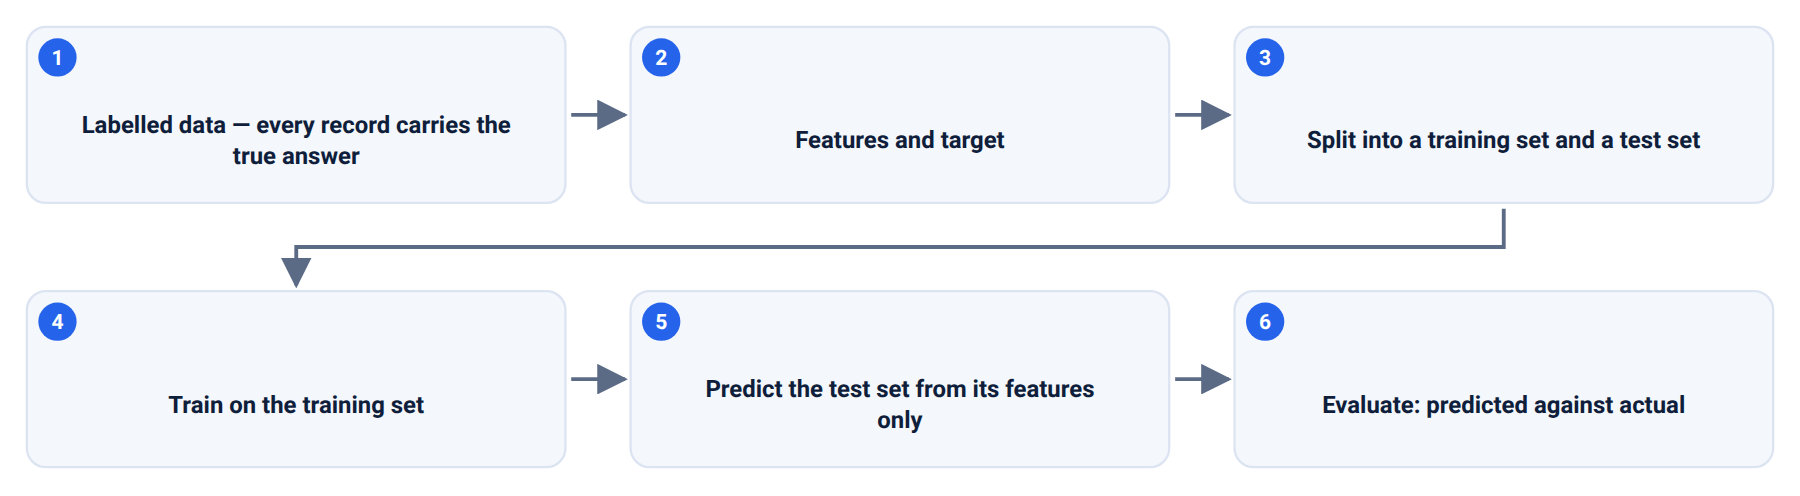

*The workflow of supervised learning. Part 10.1 carries out steps 1 to 4 and the prediction of step 5; Part 10.2 is step 6.*

> **The point that matters most.** The test set does have the real answers — they are simply hidden from the model while it predicts. Only afterwards are they uncovered and compared. That is what makes the score honest: the model could not have memorized them.



#### Two kinds of answer

What the target is decides the kind of task. When the target is a **category** — play or not, approve or decline — the task is **classification**, the subject of Parts 10.1 and 10.2. When it is a **number** — a price, a sales figure — the task is **regression**, the subject of Part 10.3. The workflow is the same; only the type of answer differs.

| Kind of classification | Number of classes | Examples |
|---|---|---|
| **Binary** | two | spam / not spam · churn / stay · approved / not approved · play / do not play |
| **Multi-class** | three or more | low / medium / high risk · bronze / silver / gold customer · which of five products a shopper buys next |

In a binary problem one of the two classes is named the **positive class** — the one being looked for, such as the churners or the days golf was played — and the evaluation in Part 10.2 is built around it. The **decision tree** handles both kinds without changing shape, and it is the one algorithm this chapter works through, because a person can read its answer, follow the path that produced it, and explain it to whoever must act on it.



## 10.1.2 · The decision tree

*the model and its terms*

> **Definition.** A **decision tree** is a hierarchical, tree-shaped model used for both classification and regression. One attribute is tested at each node, and every path from the **root node** ends in a **leaf node** that holds a prediction. To classify a new record, start at the root and follow the branch matching each test until a leaf is reached.

| Term | Meaning |
|---|---|
| **Root node** | The first attribute used to divide the data |
| **Branch / sub-tree** | A part of the whole tree |
| **Splitting** | Dividing a node into two or more sub-nodes |
| **Decision node** | An internal node that is split further |
| **Leaf node** | The end of a branch — a final prediction |
| **Pruning** | Removing a sub-node from the tree |



#### The anatomy of a tree

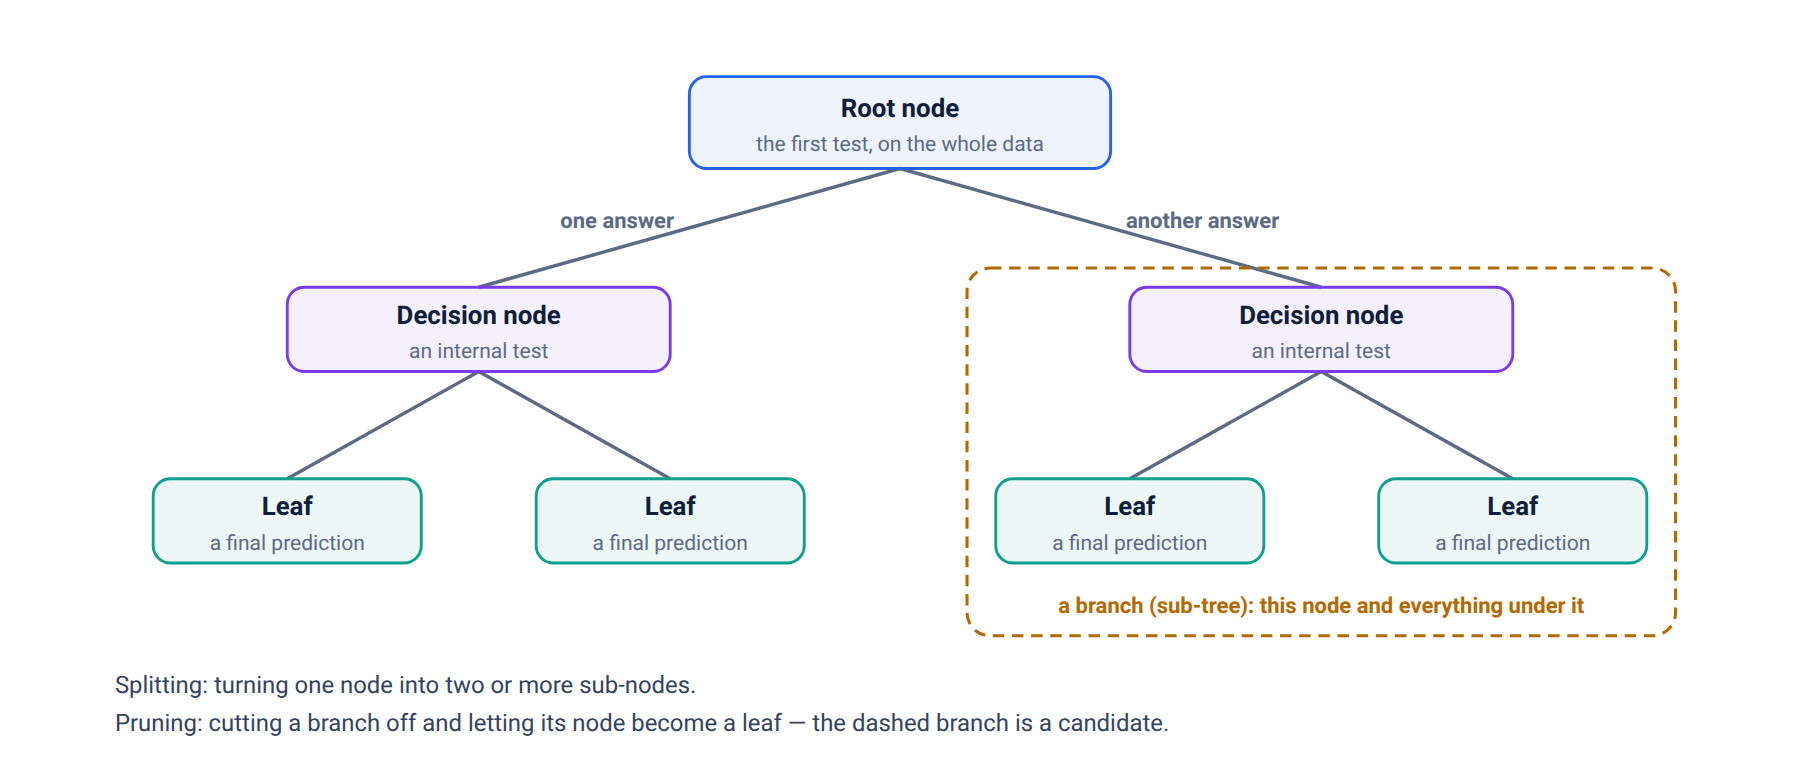

*The anatomy of a decision tree. Classifying a new record means starting at the root and following one branch per test until a leaf is reached.*

> **Two directions through the same tree.** **Deduction** — classifying a new case — walks root to leaf, applying one test per node. **Induction** — building the tree — is the reverse: learning those tests from labeled training data. Sections 10.1.3 to 10.1.5 are induction; Section 10.1.6 is deduction.



## 10.1.3 · The fourteen golf days

*the training data*

The running example is fourteen days of weather and one fact about each: whether golf was played. Four features — outlook, temperature, humidity and wind — and one target, play. Nine days are Yes and five are No. Every row already carries its answer; that is what lets a tree be grown from it, and what the tree will later be checked against.

| Day | Outlook | Temp | Humidity | Windy | Play |
|---|---|---|---|---|---|
| 1 | Rainy | Hot | High | No | **No** |
| 2 | Rainy | Hot | High | Yes | **No** |
| 3 | Overcast | Hot | High | No | **Yes** |
| 4 | Sunny | Mild | High | No | **Yes** |
| 5 | Sunny | Cool | Normal | No | **Yes** |
| 6 | Sunny | Cool | Normal | Yes | **No** |
| 7 | Overcast | Cool | Normal | Yes | **Yes** |
| 8 | Rainy | Mild | High | No | **No** |
| 9 | Rainy | Cool | Normal | No | **Yes** |
| 10 | Sunny | Mild | Normal | No | **Yes** |
| 11 | Rainy | Mild | Normal | Yes | **Yes** |
| 12 | Overcast | Mild | High | Yes | **Yes** |
| 13 | Overcast | Hot | Normal | No | **Yes** |
| 14 | Sunny | Mild | High | Yes | **No** |



#### The steps

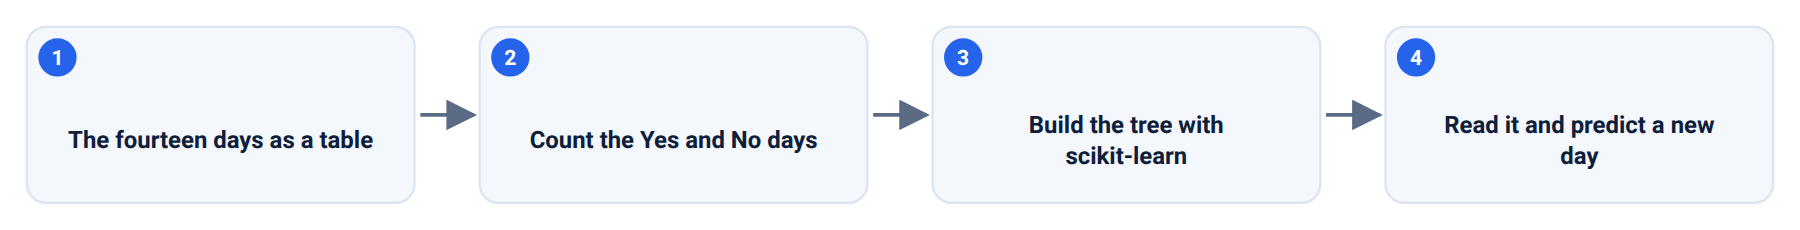

*What the cells of Sections 10.1.3 to 10.1.5 do.*



#### The golf table

The fourteen days go into a pandas table, one row per day, with the four features and the target as columns. The day numbers of the table above are the row index plus one.



In [2]:
golf = pd.DataFrame({
    "outlook":  ["Rainy", "Rainy", "Overcast", "Sunny", "Sunny", "Sunny", "Overcast",
                 "Rainy", "Rainy", "Sunny", "Rainy", "Overcast", "Overcast", "Sunny"],
    "temp":     ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                 "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "humidity": ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                 "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "windy":    ["No", "Yes", "No", "No", "No", "Yes", "Yes",
                 "No", "No", "No", "Yes", "Yes", "No", "Yes"],
    "play":     ["No", "No", "Yes", "Yes", "Yes", "No", "Yes",
                 "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"],
})
golf.index = range(1, 15)          # number the rows 1 to 14, like the days
FEATURES = ["outlook", "temp", "humidity", "windy"]
golf

,outlook,temp,humidity,windy,play
1,Rainy,Hot,High,No,No
2,Rainy,Hot,High,Yes,No
3,Overcast,Hot,High,No,Yes
4,Sunny,Mild,High,No,Yes
5,Sunny,Cool,Normal,No,Yes
6,Sunny,Cool,Normal,Yes,No
7,Overcast,Cool,Normal,Yes,Yes
8,Rainy,Mild,High,No,No
9,Rainy,Cool,Normal,No,Yes
10,Sunny,Mild,Normal,No,Yes


#### Nine Yes, five No

Before any question is asked, the whole table is one group. `value_counts()` counts how many days fall in each class of the target. The group is mixed, so a question is needed to sort it.



> **Interpretation.** Nine Yes and five No. If the tree had to answer without asking anything, it would say Yes for every day and be right nine times in fourteen. Every question it asks is an attempt to do better than that.



In [3]:
golf["play"].value_counts()

play
Yes    9
No     5
Name: count, dtype: int64

## 10.1.4 · Growing the tree with scikit-learn

*one line to build the model*

Growing a tree means choosing which question to ask first, then which to ask inside each group the answer makes. The algorithm tries every feature, keeps the one that sorts the days best, and repeats inside any group that is still mixed. A library does all of it in one line, and the rest of this section reads what it built.

1. **Start with all the days in one group** — If they all agree, stop: that answer is the prediction. If they are mixed, a question is needed.
2. **Try every feature as the question** — Keep the one that leaves its groups least mixed. It becomes a node; each answer becomes a branch.
3. **Repeat inside each mixed branch** — Only that branch's days, only the features not yet used.
4. **Stop when every branch is settled** — Each finished group is a leaf. The tree is the model.



#### The steps

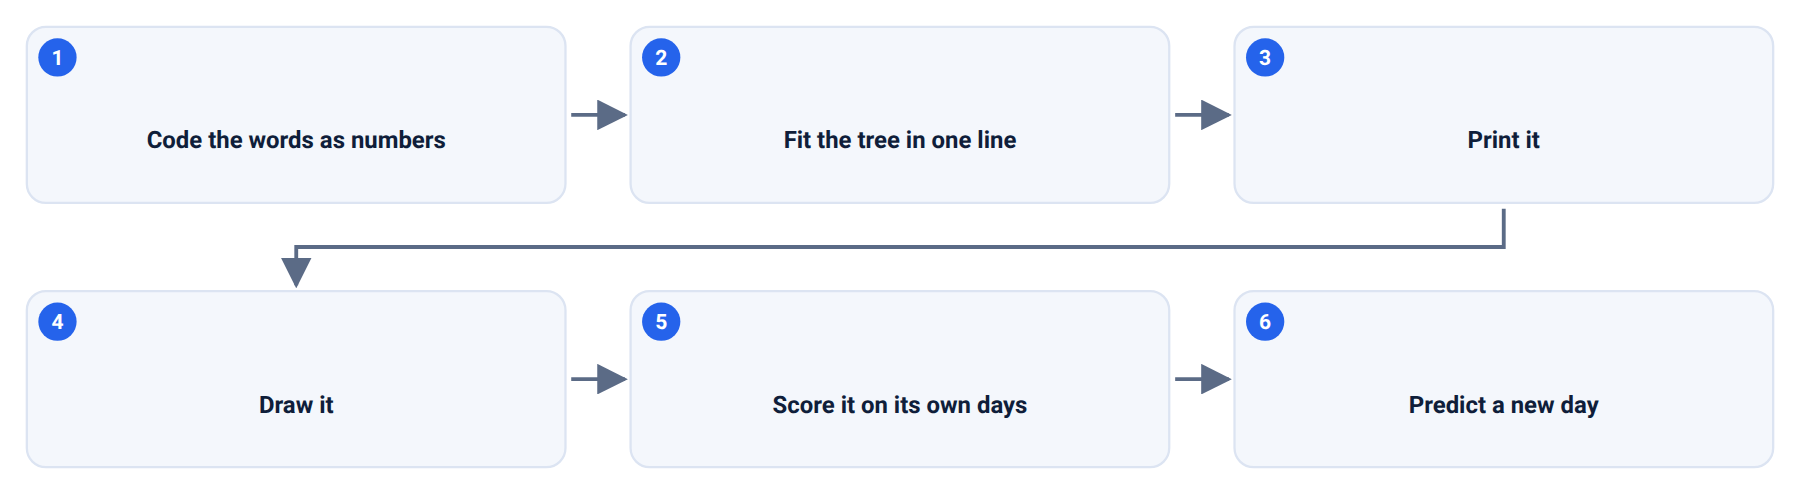

*What the cells below do.*



#### Text into numbers

scikit-learn reads numbers, so each column of words becomes a column of whole numbers: `.astype('category').cat.codes` numbers the values of a column in alphabetical order — outlook becomes Overcast 0, Rainy 1, Sunny 2; humidity High 0, Normal 1; windy No 0, Yes 1. The column names do not change.



> **Interpretation.** The same table, in numbers. Day 1 is Rainy, Hot, High, not windy, so it reads 1, 1, 0, 0 — the numbers are labels, not quantities.



In [4]:
codes = golf[FEATURES].apply(lambda col: col.astype("category").cat.codes)
codes.head()

,outlook,temp,humidity,windy
1,1,1,0,0
2,1,1,0,1
3,0,1,0,0
4,2,2,0,0
5,2,0,1,0


#### The tree in one line

`DecisionTreeClassifier()` makes an empty tree and `.fit(features, target)` grows it from the fourteen days. `random_state` only fixes how ties are broken, so that everyone gets the same tree.



> **Interpretation.** Four questions deep, with seven leaves. That is the model; the next two cells show what it asks.



In [5]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

model = DecisionTreeClassifier(random_state=0).fit(codes, golf["play"])
print("depth", model.get_depth(), "· leaves", model.get_n_leaves())

depth 4 · leaves 7


#### The tree, printed

`export_text` prints the tree as indented rules. A line such as `outlook <= 0.50` asks whether the outlook code is 0 or less — that is, whether it is Overcast — and the lines indented below it are what follows when the answer is yes.



> **Interpretation.** The first question is outlook, and the overcast days reach a leaf at once: every overcast day was played, so nothing more need be asked about them. Each branch below keeps asking until its group agrees. Note that the questions are yes-or-no: the tree asks *is it overcast* rather than *what is the outlook*, so separating three outlooks takes two questions.



In [6]:
print(export_text(model, feature_names=list(codes.columns), class_names=list(model.classes_)))

|--- outlook <= 0.50
|   |--- class: Yes
|--- outlook >  0.50
|   |--- humidity <= 0.50
|   |   |--- outlook <= 1.50
|   |   |   |--- class: No
|   |   |--- outlook >  1.50
|   |   |   |--- windy <= 0.50
|   |   |   |   |--- class: Yes
|   |   |   |--- windy >  0.50
|   |   |   |   |--- class: No
|   |--- humidity >  0.50
|   |   |--- windy <= 0.50
|   |   |   |--- class: Yes
|   |   |--- windy >  0.50
|   |   |   |--- temp <= 1.00
|   |   |   |   |--- class: No
|   |   |   |--- temp >  1.00
|   |   |   |   |--- class: Yes



#### The tree, drawn

`plot_tree` draws the same tree. Each box shows the question, how many days reached it (`samples`), how they split between No and Yes (`value`), and the class the box would answer.



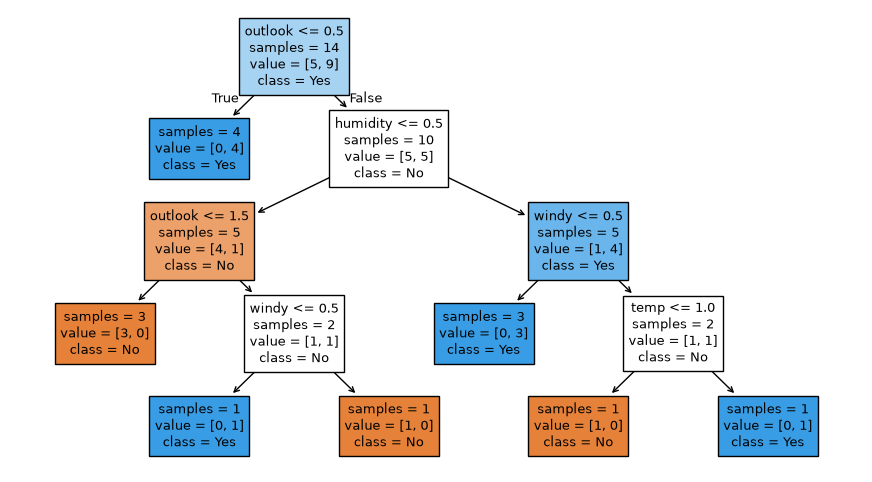

In [7]:
plt.figure(figsize=(11, 6))
plot_tree(model, feature_names=list(codes.columns), class_names=list(model.classes_),
          filled=True, impurity=False, fontsize=9)
plt.show()

#### What the chart shows

> **Interpretation.** Read it from the top: the root splits the fourteen days on outlook, the left box is the four overcast days and is already settled, and every path down the right-hand side ends in a box whose days agree.



#### The tree on its own fourteen days

`.score(features, target)` predicts every row and reports the share it gets right — the training accuracy.



> **Interpretation.** 1.0 — right on all fourteen. The algorithm kept asking questions until every group agreed, so it cannot be wrong on the days it was grown from. That is how well the tree fits, not how well it predicts: Part 10.2 asks it about days it has not seen.



In [8]:
model.score(codes, golf["play"])

1.0

#### Predicting a new day

A new day is written as a one-row table. It has to be coded in the same numbers as the training table, so it is joined to the fourteen days before coding and the last row is taken.



> **Interpretation.** No. A sunny, windy day with high humidity: the tree walks from the root to a leaf that says the day would not be played.



In [9]:
new_day = {"outlook": "Sunny", "temp": "Mild", "humidity": "High", "windy": "Yes"}
day_codes = (pd.concat([golf[FEATURES], pd.DataFrame([new_day])])
               .apply(lambda col: col.astype("category").cat.codes).tail(1))
model.predict(day_codes)[0]

'No'

## 10.1.5 · Reading the tree

*IF–THEN rules*

Every path from the root to a leaf is one **IF–THEN rule**, and the printed tree above is seven of them. This is the form a business can act on, and it is why the decision tree is the algorithm this chapter works through.

- IF overcast THEN play
- IF not overcast AND humidity is high AND rainy THEN do not play
- IF not overcast AND humidity is high AND sunny AND not windy THEN play
- … one rule for each of the remaining leaves

A prediction is one rule applied: the new day above matched a path ending in No, so the answer was No. The prediction can then be compared with what actually happened, which is the comparison Part 10.2 is built on.



#### Where Part 10.1 leaves us

> **Key idea.** A tree was grown from fourteen labeled days in one line, printed, drawn and read as rules; it predicts a new day by walking root to leaf, and it scores 100% on the days it was grown from. Part 10.2 asks it about days it has not seen. The rest of this part applies the same three lines to a real dataset, so the in-class exercise can be done on another one.



## 10.1.6 · A real dataset — the iris flowers

*the same method with scikit-learn*

Fourteen rows can be worked by hand. Real datasets cannot, so the method is now applied with a library. The dataset is one of the oldest in statistics: 150 iris flowers measured by the botanist Edgar Anderson and published by Ronald Fisher in 1936 — 50 flowers of each of three species, and four measurements of each flower, in centimeters: the length and width of the sepal (the outer leaf of the flower) and of the petal. It is bundled with scikit-learn, so it loads without a download.

> **The question.** Can a flower's species be told from its four measurements — and what rules does the tree find? The target is the species: three classes, so this is a multi-class problem. The features are the four measurements.

> **The library.** scikit-learn's `DecisionTreeClassifier` grows a tree the way Section 10.1.4 did, with one difference: its features are numbers, so a question is a cut-point — “petal width ≤ 0.8?” — that sends each flower left or right, and the algorithm tries cut-points the way the golf tree tried its four features, scoring how mixed the two groups are with a formula rather than a count. The idea is the same: keep the question that leaves its groups least mixed, then search again inside each mixed group.



#### The steps

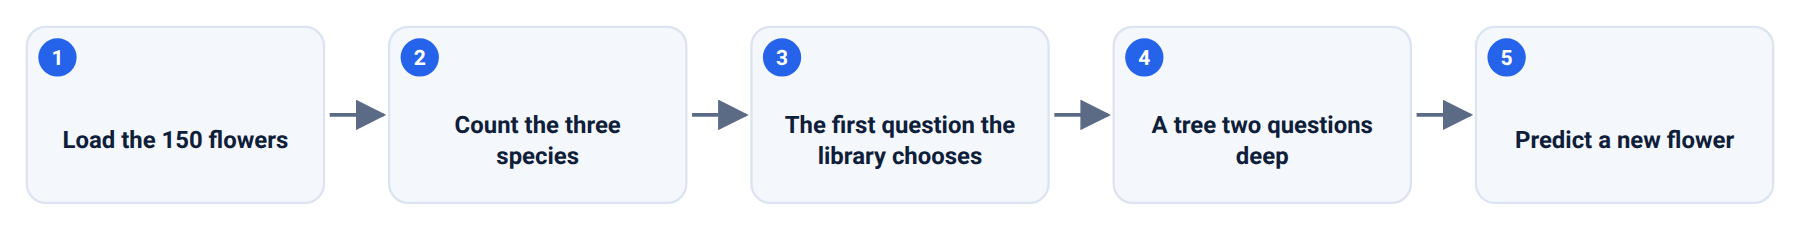

*The iris walk.*



#### Loading the flowers

`load_iris(as_frame=True)` returns the data as a pandas table plus the species of each flower as a number 0, 1, 2, with the names in a separate list. The cell renames the columns to short names, adds a species column with the names, and shows the first rows.



> **Interpretation.** 150 rows and 5 columns: four measurements in centimeters and the species. The first flowers are all setosa, because the file is sorted by species.



In [10]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
flowers = iris.data.copy()
flowers.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
flowers["species"] = iris.target_names[iris.target]     # 0/1/2 -> setosa / versicolor / virginica
print("shape:", flowers.shape)
flowers.head()

shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### Three species, fifty each

As with the golf days, the whole table is first one group; the count of each class says how mixed it is.



> **Interpretation.** 50 setosa, 50 versicolor, 50 virginica. A tree that asked nothing would be right one time in three.



In [11]:
flowers["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

#### The first question the library chooses

`DecisionTreeClassifier(max_depth=1)` grows a tree of one question. `.fit(X, y)` is the training step: the features `X` and the target `y` go in, and the tree comes back. `export_text` prints it as indented rules, the way Section 10.1.5 printed the golf tree.



> **Interpretation.** One question — petal width ≤ 0.8 cm — sends every setosa left and every other flower right. The left group is pure, like the Overcast branch of the golf tree; the right group still mixes versicolor and virginica, so it needs another question.



In [12]:
from sklearn.tree import DecisionTreeClassifier, export_text

X = flowers[["sepal_length", "sepal_width", "petal_length", "petal_width"]]
y = flowers["species"]

stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X, y)
print(export_text(stump, feature_names=list(X.columns), class_names=list(stump.classes_)))

|--- petal_width <= 0.80
|   |--- class: setosa
|--- petal_width >  0.80
|   |--- class: versicolor



#### A tree two questions deep

Raising `max_depth` to 2 lets the algorithm ask one more question inside the mixed group. The cell prints the tree and its training accuracy — `.score(X, y)` is the share of the 150 flowers the tree gets right.



> **Interpretation.** The second question is petal width again, at 1.75 cm: at most 1.75 is called versicolor, above it virginica. Three leaves and 96% on the training flowers — the two right-hand leaves are not pure, so six flowers land in a leaf whose answer is not their species.



In [13]:
tree2 = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X, y)
print(export_text(tree2, feature_names=list(X.columns), class_names=list(tree2.classes_)))
print(f"training accuracy: {tree2.score(X, y):.1%}")

|--- petal_width <= 0.80
|   |--- class: setosa
|--- petal_width >  0.80
|   |--- petal_width <= 1.75
|   |   |--- class: versicolor
|   |--- petal_width >  1.75
|   |   |--- class: virginica

training accuracy: 96.0%


#### Predicting a new flower

`.predict()` walks a new flower through the tree. The flower is written as a one-row table with the same four columns, in the same order, as the training data.



> **Interpretation.** Versicolor. Its petal width of 1.5 cm fails the first test (it is more than 0.8) and passes the second (at most 1.75), so it lands in the versicolor leaf — the same walk as the sunny, windy day, with cut-points in place of categories.



In [14]:
new_flower = pd.DataFrame([[5.8, 3.0, 4.5, 1.5]], columns=X.columns)
print("petal width 1.5 -> not <= 0.8, and <= 1.75 ->", tree2.predict(new_flower)[0])

petal width 1.5 -> not <= 0.8, and <= 1.75 -> versicolor


#### From here

> **Key idea.** The golf tree and the iris tree are the same object: a sequence of questions chosen from labeled data, ending in leaves that answer. What changes with a real dataset is only the tool. The exercise below continues with the flowers: a deeper tree, its rules, new flowers to classify, and a question about which measurements ask the better questions.



## 10.1.7 · Glossary

*the terms of this part*

| Term | Meaning |
|---|---|
| **Supervised learning** | Learning from data that already carries the answers (the target). |
| **Feature / target** | A column used to predict / the column to be predicted. |
| **Training set / test set** | The rows a model learns from / the rows it is judged on, hidden while it learns. |
| **Classification / regression** | Predicting a category / predicting a number. |
| **Binary / multi-class** | Two classes / three or more. |
| **Positive class** | In a binary problem, the class being looked for. |
| **Decision tree** | A model that asks one question per node; every path from the root ends in a prediction. |
| **Root, decision node, leaf** | The first question, an inner question, a final answer. |
| **Pure group** | A group whose members all have the same class; it needs no further question. |
| **Settled by majority** | The days a group's most common class gets right; the feature's total is its score. |
| **IF–THEN rule** | One path from the root to a leaf, written as conditions and an answer. |
| **Training accuracy** | The share of the training rows a model gets right — how well it fits, not how well it predicts. |



## 10.1.8 · In-class exercise

*load new data, build the model*

Three short steps on a dataset this part has not used: 178 wines from three growers, with 13 chemical measurements of each. Everything you need is in Section 10.1.4 — load the data, fit the tree, read it. Finish it in class and hand it in for participation.

**Student information** — double-click this cell to edit it and fill in your details.

**Name:** ____________________________

**Student ID:** ______________________

**Date:** ____________________________



#### The data — 178 wines

*run this cell, but do not modify it*

Run this cell once and do not edit it. It loads the wines, puts the 13 measurements in `X` and the grower in `y`, and prints how many wines each grower made. The measurements are already numbers, so nothing has to be coded.



In [15]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, export_text

wine = load_wine(as_frame=True)
X = wine.data                                  # 13 measurements of each wine
y = wine.target_names[wine.target]             # the grower: class_0, class_1 or class_2
print("wines:", X.shape, "· measurements:", list(X.columns)[:4], "...")
pd.Series(y).value_counts()

wines: (178, 13) · measurements: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash'] ...


class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

#### Exercise 1 — Build the tree

Make a tree two questions deep and fit it to the wines, in one line: `DecisionTreeClassifier(max_depth=2, random_state=0).fit(X, y)`, stored as `model`. Then print how well it does on its own wines with `model.score(X, y)`. Report that number.



In [16]:
# YOUR CODE HERE (Exercise 1)

#### Your answer — Exercise 1

*Double-click this cell and type your answer here.*



#### Exercise 2 — Read the tree

Print the tree with `print(export_text(model, feature_names=list(X.columns)))`. Which measurement is the first question, and what is the cut-off value?



In [17]:
# YOUR CODE HERE (Exercise 2)

#### Your answer — Exercise 2

*Double-click this cell and type your answer here.*



#### Exercise 3 — Predict three wines

Ask the tree about wines 0, 70 and 160 — one from each grower: `predicted = model.predict(X.iloc[[0, 70, 160]])`, and take the true growers as `actual = y[[0, 70, 160]]`. Put the two side by side with `pd.DataFrame({"predicted": predicted, "actual": actual})` and count the ones that match: `int((predicted == actual).sum())` compares the two lists value by value and adds up the matches, because True counts as 1. How many of the three does the tree get right?



In [18]:
# YOUR CODE HERE (Exercise 3)

#### Your answer — Exercise 3

*Double-click this cell and type your answer here.*



#### Before you hand it in

> **Checklist.** Three things:
>
> - Your name and student ID filled in at the top
> - Every cell run in order, with its output showing
> - A sentence of your own in each answer cell

